In [55]:
using ITensors
using ITensorMPS
using JLD2
using Plots
using LaTeXStrings
using Printf




In [56]:
using JLD2
using Printf

data_dir = joinpath(@__DIR__, "data")

# all_data[sigma][truncation] = loaded_data_dict 
all_data = Dict{Float64, Dict{Float64, Any}}() 

sigma_values = [0.0, 5e-7, 6e-7, 7e-7, 8e-7, 9e-7, 1e-6, 2e-6, 3e-6, 4e-6, 5e-6] 
trunc_values = [1e-16, 1e-15, 1e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8] 

println("Searching in: ", data_dir)

for σ in sigma_values
    all_data[σ] = Dict{Float64, Any}()
    
    current_trunc_list = (σ == 0.0) ? [1e-16] : trunc_values
    
    for trunc in current_trunc_list

        sigma_str = replace(@sprintf("%.1e", σ))
        trunc_str = replace(@sprintf("%.1e", trunc))
        if σ == 0.0
            sigma_str = "0.0e+00"
        end

        file_name = "data_fid_$(trunc_str)_$(sigma_str).jld2" 
        file_path = joinpath(data_dir, file_name) 
        
        if isfile(file_path) 
            try
                data = load(file_path)
                all_data[σ][trunc] = data 
                println("Successfully loaded: σ=$sigma_str, Trunc=$trunc_str")
            catch e
                println("ERROR loading file: $file_name -> $e")
            end
        end
    end
end


Searching in: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Fidelity\data
Successfully loaded: σ=0.0e+00, Trunc=1.0e-16
Successfully loaded: σ=5.0e-07, Trunc=1.0e-16
Successfully loaded: σ=5.0e-07, Trunc=1.0e-15
Successfully loaded: σ=6.0e-07, Trunc=1.0e-16
Successfully loaded: σ=7.0e-07, Trunc=1.0e-15


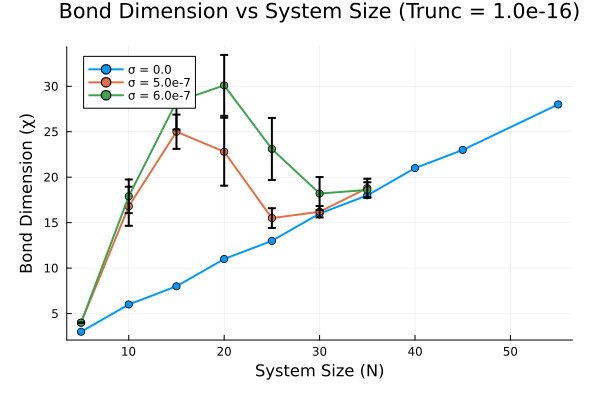

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\bd.png"

In [57]:
target_sigmas = [0.0, 5e-7, 6e-7] 
target_trunc = 1e-16


p_bd = plot(
    title = "Bond Dimension vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,    
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, σ) && haskey(all_data[σ], target_trunc)
        data = all_data[σ][target_trunc]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        

        if σ == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    end
end

display(p_bd)
savefig(p_bd, joinpath("images", "bd.png"))



# Fidelity


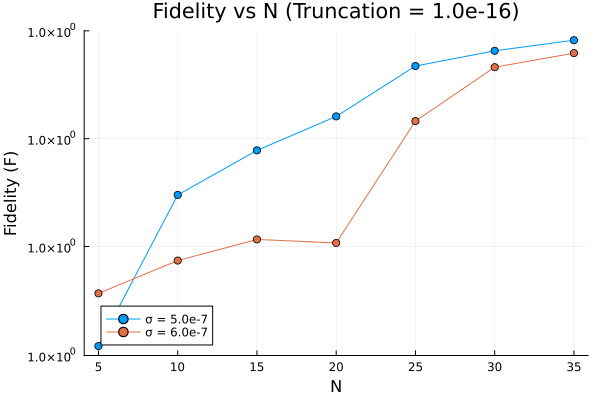

In [70]:
target_trunc = 1e-16
sigmas_to_plot = [5e-7, 6e-7] 

# Initialize plot with a linear scale and fixed Y-axis limits
p_fid = plot(title="Fidelity vs N (Truncation = $target_trunc)",
             xlabel="N", ylabel="Fidelity (F)",
            #  ylim=(0, 1.05),           # Linear scale, forces view from 0 to 1
             legend=:bottomleft, 
             marker=:circle)

clean_dict = all_data[0.0][1e-16]
clean_mps_arr = clean_dict["mps_arr"]
clean_N_vals = clean_dict["N_range"]

for σ in sigmas_to_plot
    if haskey(all_data, σ) && haskey(all_data[σ], target_trunc)
        current_data = all_data[σ][target_trunc]
        current_mps_arr = current_data["mps_arr"]
        current_N_vals = current_data["N_range"]
        
        fidelities = Float64[]
        valid_N = Int[]
        
        for (i, N) in enumerate(current_N_vals)
            clean_idx = findfirst(x -> x == N, clean_N_vals)
            
            if clean_idx !== nothing && !ismissing(clean_mps_arr[clean_idx]) && !ismissing(current_mps_arr[i])
                
                # Extract first sample
                ψ_clean = clean_mps_arr[clean_idx][1] 
                ψ_noisy = current_mps_arr[i][1]
                
                # Compute fidelity
                fid = abs(inner(ψ_clean, ψ_noisy))^2
                
                push!(fidelities, fid)
                push!(valid_N, N)
            end
        end
        
        if !isempty(fidelities)
            # FIXED: Changed p_infid to p_fid
            plot!(p_fid, valid_N, fidelities, label="σ = $σ", marker=:circle)
        end
    else
        println("Data missing for σ=$σ at Trunc=$target_trunc")
    end
end

display(p_fid)

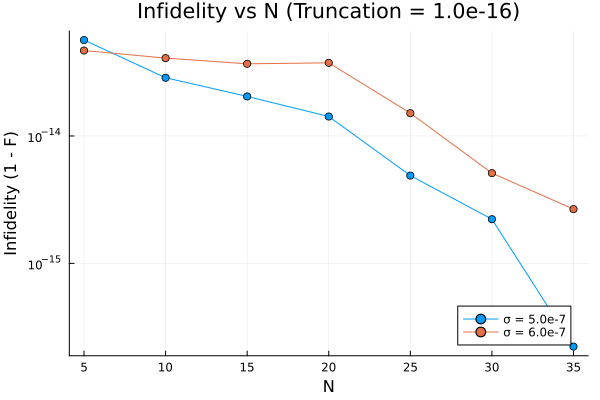

In [ ]:
target_trunc = 1e-16
sigmas_to_plot = [5e-7, 6e-7] 

# Initialize plot with a log scale for the Y-axis
p_infid = plot(title="Infidelity vs N (Truncation = $target_trunc)",
               xlabel="N", ylabel="Infidelity (1 - F)",
               yaxis=:log10,           # Logarithmic scale
               legend=:bottomright, 
               marker=:circle)

clean_dict = all_data[0.0][1e-16]
clean_mps_arr = clean_dict["mps_arr"]
clean_N_vals = clean_dict["N_range"]

for σ in sigmas_to_plot
    if haskey(all_data, σ) && haskey(all_data[σ], target_trunc)
        current_data = all_data[σ][target_trunc]
        current_mps_arr = current_data["mps_arr"]
        current_N_vals = current_data["N_range"]
        
        infidelities = Float64[]
        valid_N = Int[]
        
        for (i, N) in enumerate(current_N_vals)
            clean_idx = findfirst(x -> x == N, clean_N_vals)
            
            if clean_idx !== nothing && !ismissing(clean_mps_arr[clean_idx]) && !ismissing(current_mps_arr[i])
                
                # Extract first sample
                ψ_clean = clean_mps_arr[clean_idx][1] 
                ψ_noisy = current_mps_arr[i][1]
                
                # Compute fidelity and then infidelity
                fid = abs(inner(ψ_clean, ψ_noisy))^2
                infid = 1.0 - fid
                
                infid = max(infid, 1e-16) 
                
                push!(infidelities, infid)
                push!(valid_N, N)
            end
        end
        
        if !isempty(infidelities)
            plot!(p_infid, valid_N, infidelities, label="σ = $σ", marker=:circle)
        end
    else
        println("Data missing for σ=$σ at Trunc=$target_trunc")
    end
end

display(p_infid)